In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path):
    for path in (start.resolve(), *start.resolve().parents):
        if (path / "data" / "gold").is_dir():
            return path
    return None


IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = find_project_root(Path.cwd())

if PROJECT_ROOT is None and IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    PROJECT_ROOT = find_project_root(
        Path("drive/MyDrive/IE403/LAMLAI/sentiment-analysis-game-domain")
    )
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Cannot find the repository root containing data/gold."
    )

print(f"Environment: {'Google Colab' if IN_COLAB else 'local'}")
print(f"Project root: {PROJECT_ROOT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Google Colab
Project root: /content/drive/MyDrive/IE403/LAMLAI/sentiment-analysis-game-domain


In [2]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("Enable a GPU runtime in Colab before training.")


CUDA available: True
GPU: Tesla T4
GPU memory: 14.6 GB


In [3]:
if IN_COLAB:
    import subprocess

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "transformers", "optuna", "iterative-stratification", "sentencepiece"
    ])


In [4]:
# XLM-RoBERTa is downloaded automatically by Hugging Face on first use.


### Library

In [5]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, classification_report, recall_score, precision_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import optuna
from functools import partial

In [6]:
DATA_DIR = PROJECT_ROOT / "data" / "gold"
train_path = DATA_DIR / "train.csv"
val_path = DATA_DIR / "val.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path, encoding="utf-8")
dev_df = pd.read_csv(val_path, encoding="utf-8")
test_df = pd.read_csv(test_path, encoding="utf-8")
print(f"train - val - test: {train_df.shape}, {dev_df.shape}, {test_df.shape}")


train - val - test: (4152, 11), (519, 11), (519, 11)


In [7]:
# Parameters
XLM_ROBERTA_MODEL_BASE = "FacebookAI/xlm-roberta-base"
TEXT_COL = "review"
MAX_LEN = 128
NUM_EPOCHS = 10
ASPECT_COLS = [
    "graphics", "matchmaking", "store & microtransactions", "technical_issue",
    "mechanics", "developer_support", "event", "community", "hero_design", "difficulty"
]


### Checkpoint

In [8]:
CHECKPOINT_DIR = PROJECT_ROOT / "artifacts" / "checkpoints" / "xlm-roberta-base"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "predictions" / "xlm-roberta-base"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def checkpoint_path():
    return CHECKPOINT_DIR / "best_xlm_roberta_base.pt"


Using device: cuda


In [9]:
# dataset
class ASBADataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
      self.texts = texts
      self.labels = labels
      self.tokenizer = tokenizer
      self.max_len = max_len

    def __len__(self):
      return len(self.texts)

    def __getitem__(self, idx):
      text = str(self.texts.iloc[idx])
      labels = self.labels.iloc[idx].values.astype(int)
      #tokenize
      encoding = self.tokenizer(
        text,
        # nếu text > max_len -> bỏ
        truncation = True,
        # chạy GPU nên cấu hình pad để tất cả tensor trong batch cùng kích thước
        padding = "max_length",
        max_length = self.max_len,
        return_tensors = "pt"
      )
      return {
        "input_ids": encoding["input_ids"].flatten(),
        "attention_mask": encoding["attention_mask"].flatten(),
        "labels": torch.tensor(labels, dtype=torch.long)
      }

class XLMRobertaMultiHeadClassifier(nn.Module):
    def __init__(self, model_name, num_aspects=len(ASPECT_COLS), num_classes=3, dropout=0.3):
      super().__init__()
      self.encoder = AutoModel.from_pretrained(model_name)
      self.dropout = nn.Dropout(dropout)
      hidder_size = self.encoder.config.hidden_size
      # dùng 10 linear head để mỗi head học lập lập và gán trọng số riêng cho từng aspect
      classifier_list = []
      for _ in range(num_aspects):
        classifier_list.append(nn.Linear(hidder_size, num_classes))
      self.classifier = nn.ModuleList(classifier_list)

    def forward(self, input_ids, attention_mask):
      outputs = self.encoder(
        input_ids = input_ids,
        attention_mask = attention_mask
      )
      # cls_output = outputs.last_hidden_state[:, 0, :]
      last_hidden = outputs.last_hidden_state
      mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
      masked_embeddings = last_hidden * mask
      sum_embeddings = masked_embeddings.sum(dim=1)
      sum_mask = mask.sum(dim=1).clamp(min=1e-9)
      cls_output = sum_embeddings / sum_mask
      x = self.dropout(cls_output)
      output_logits = []
      for clf in self.classifier:
        output_logits.append(clf(x))
      return output_logits

def get_criterion():
    criterions = []
    for col in ASPECT_COLS:
      criterions.append(nn.CrossEntropyLoss())
    return criterions

# tính tổng loss
def loss_function(logits_list, labels, criterions):
    # logits_list: dự đoán aspect --> (batch, 3)
    # labels: nhãn thật của aspect --> (batch, 10)
    loss = 0
    for i, (logits, criterion) in enumerate(zip(logits_list, criterions)):
      loss += criterion(logits, labels[:,i])
    return loss / len(ASPECT_COLS)

def pred_per_aspect_accuracy(preds, labels):
    # preds: (batch, 10) -> nhãn dự đoán
    # label: (batch, 10) -> nhãn thật
    matches = (preds == labels)
    correct_aspect = matches.sum(dim=0)
    return correct_aspect, labels.size(0)

def train_epoch(model, loader, optimizer, scheduler, criterions):
    model.train()
    total_loss = 0
    total_correct = torch.zeros(len(ASPECT_COLS))
    total = 0
    for batch in tqdm(loader, desc="Training", leave=False):
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      # reset gradient
      optimizer.zero_grad()
      logits_list = model(input_ids, attention_mask)
      loss = loss_function(logits_list, labels, criterions)
      # tính gradient
      loss.backward()

      # chặn gradient ko bị bùng nổ khi backprop qua nhiều lớp do có nhiều layer
      nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step() # cập nhật lại trọng số
      scheduler.step() # giảm learning rate

      preds_list = []
      for l in logits_list:
          preds_list.append(l.argmax(-1))
      preds = torch.stack(preds_list, dim=1)
      correct_aspect, n = pred_per_aspect_accuracy(preds, labels)
      total_correct += correct_aspect.cpu()
      total += n
      total_loss += loss.item() * labels.size(0)
    avg_loss = total_loss / total
    aspect_accuracy = (total_correct / total).tolist()
    avg_acc = float(total_correct.sum()/ (total * len(ASPECT_COLS)))
    return avg_loss, avg_acc, aspect_accuracy

def evaluate(model, loader, criterions):
    model.eval()
    total_loss = 0
    total_correct = torch.zeros(len(ASPECT_COLS))
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
      for batch in tqdm(loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits_list = model(input_ids, attention_mask)
        loss = loss_function(logits_list, labels, criterions)
        preds_list = []
        for l in logits_list:
            preds_list.append(l.argmax(-1))
        preds = torch.stack(preds_list, dim=1)
        correct_aspect,n = pred_per_aspect_accuracy(preds, labels)
        total_correct += correct_aspect.cpu()
        total_loss += loss.item() * n
        total += n
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss = total_loss / total
    aspect_acc = (total_correct / total).tolist()
    avg_acc = float(total_correct.sum() / (total * len(ASPECT_COLS)))
    precision_aspect = []
    recall_aspect = []
    f1_aspect = []
    for i in range(len(ASPECT_COLS)):
      precision = precision_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      recall = recall_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      f1 = f1_score(all_labels[:, i], all_preds[:, i], average="macro", zero_division=0)
      precision_aspect.append(precision)
      recall_aspect.append(recall)
      f1_aspect.append(f1)
    avg_precision = float(np.mean(precision_aspect))
    avg_recall = float(np.mean(recall_aspect))
    avg_f1 = float(np.mean(f1_aspect))
    return avg_loss, avg_acc, aspect_acc, avg_precision, avg_recall, avg_f1, all_preds, all_labels, precision_aspect, recall_aspect, f1_aspect

def save_checkpoint(epoch, model, optimizer, scheduler, dev_loss, dev_f1, dev_recall, path):
  torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "scheduler_state": scheduler.state_dict(),
    "dev_loss": dev_loss,
    "dev_f1": dev_f1,
    "dev_recall": dev_recall
  }, path)
  print(f"checkpoint được lưu vào {path}")

def load_checkpoint(path, model, optimizer=None, scheduler=None):
    data = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(data["model_state"])
    if optimizer:
        optimizer.load_state_dict(data["optimizer_state"])
    if scheduler:
        scheduler.load_state_dict(data["scheduler_state"])
    print(f"checkpoint epoch {data['epoch']} với dev_f1 = {data['dev_f1']:.4f}")
    return data["epoch"]

def train(train_df, dev_df, criterions, tokenizer, lr, dropout, weight_decay, batch_size, early_stopping, model_name, num_epochs, text_col=TEXT_COL, resume=False, save_ckpt=True, trial=None):
    train_ds = ASBADataset(train_df[text_col], train_df[ASPECT_COLS], tokenizer)
    dev_ds = ASBADataset(dev_df[text_col], dev_df[ASPECT_COLS], tokenizer)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    dev_loader = DataLoader(dev_ds, batch_size=batch_size, num_workers=0, pin_memory=True)

    model = XLMRobertaMultiHeadClassifier(model_name, dropout=dropout).to(device)
    # tách weight decay khỏi gradient update giúp Phobert hộ tụ ổn định, giảm overfit và ko làm hỏng pretrain weights
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps = int(0.1 * total_steps),
        num_training_steps = total_steps
    )
    start_epoch = 0
    best_dev_f1 = -1
    best_dev_recall = -1
    best_dev_loss = float('inf')
    no_improve = 0

    BEST_MODEL_PATH = checkpoint_path()

    if resume and os.path.exists(BEST_MODEL_PATH):
      checkpoint_data = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
      start_epoch = load_checkpoint(BEST_MODEL_PATH, model, optimizer, scheduler)
      best_dev_f1 = checkpoint_data.get("dev_f1", -1)
      best_dev_recall = checkpoint_data.get("dev_recall", -1)
      best_dev_loss = checkpoint_data.get("dev_loss", float('inf'))
    for epoch in range(start_epoch, num_epochs):
      print(f"Epoch {epoch+1}/{num_epochs}:")
      train_loss, train_avg_acc, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterions)
      dev_loss, dev_acc, dev_aspect_acc, dev_precision, dev_recall, dev_f1, _, _,  precision_aspect, recall_aspect, f1_aspect = evaluate(model, dev_loader, criterions)
      print("Train:")
      print(f"loss: {train_loss:.4f}, avg_acc_aspect: {train_avg_acc:.4f}")
      print(f"accuracy: {train_acc}")
      print("Dev:")
      print(f"loss: {dev_loss:.4f}, dev_aspect_acc: {dev_aspect_acc}")
      print(f"accuracy: {dev_acc:.4f}, f1: {dev_f1:.4f}, precision: {dev_precision:.4f}, recall: {dev_recall:.4f}")
      print("Aspect:")
      for aspect, p, r, f1 in zip(ASPECT_COLS, precision_aspect, recall_aspect, f1_aspect):
          print(f"{aspect}: f1: {f1:.4f}, precision: {p:.4f}, recall: {r:.4f}")

      # save checkpoint cho mỗi epoch
      if save_ckpt:
        epoch_path = CHECKPOINT_DIR / f"checkpoint_xlm_roberta_base_epoch_{epoch+1}.pt"
        save_checkpoint(epoch+1, model, optimizer, scheduler, dev_loss, dev_f1, dev_recall, epoch_path)

      # save best model
      if dev_f1 > best_dev_f1 + 1e-4: # thêm epsilon để tránh nhiễu
        best_dev_f1 = dev_f1
        best_dev_recall = dev_recall
        best_dev_loss = dev_loss
        no_improve = 0
        if save_ckpt:
          save_checkpoint(epoch + 1, model, optimizer, scheduler, dev_loss, dev_f1, dev_recall, BEST_MODEL_PATH)
        print(f"Best model: P={dev_precision:.4f}, R={dev_recall:.4f}, F1={dev_f1:.4f}")
      # earrly stopping theo loss
      else:
          no_improve += 1
          if no_improve >= early_stopping:
              print(f"Early stopping tại epoch {epoch+1}")
              break

        # optuna để pruning - early stoping khi trial không cải thiện
      if trial is not None:
          trial.report(dev_f1, epoch)
          if trial.should_prune():
              raise optuna.TrialPruned()
    return model, best_dev_f1, best_dev_recall, best_dev_loss

print(f"Training rows: {len(train_df)}")
print("Ph?n ph?i nh?n trong train:")
for col in ASPECT_COLS:
    print(f"{col}: {train_df[col].value_counts().to_dict()}")


Training rows: 4152
Ph?n ph?i nh?n trong train:
graphics: {0: 4010, 1: 76, 2: 66}
matchmaking: {0: 2919, 2: 1215, 1: 18}
store & microtransactions: {0: 3994, 2: 133, 1: 25}
technical_issue: {2: 2075, 0: 2066, 1: 11}
mechanics: {0: 3103, 2: 980, 1: 69}
developer_support: {0: 3033, 2: 825, 1: 294}
event: {0: 4088, 1: 34, 2: 30}
community: {0: 2963, 2: 1184, 1: 5}
hero_design: {0: 4010, 2: 85, 1: 57}
difficulty: {0: 4070, 2: 72, 1: 10}


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   review                     4152 non-null   object
 1   graphics                   4152 non-null   int64 
 2   matchmaking                4152 non-null   int64 
 3   store & microtransactions  4152 non-null   int64 
 4   technical_issue            4152 non-null   int64 
 5   mechanics                  4152 non-null   int64 
 6   developer_support          4152 non-null   int64 
 7   event                      4152 non-null   int64 
 8   community                  4152 non-null   int64 
 9   hero_design                4152 non-null   int64 
 10  difficulty                 4152 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 356.9+ KB


### hyperparameter search - optuna

In [11]:
tokenizer_base = AutoTokenizer.from_pretrained(XLM_ROBERTA_MODEL_BASE, use_fast=True)
TOKENIZER = {XLM_ROBERTA_MODEL_BASE: tokenizer_base}

EARLY_STOPPING = 5
N_TRIALS = 5


def objective(trial, model_name):
    # Lấy thông tin trial và các tham số gợi ý
    lr = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    dropout = trial.suggest_float("dropout", 0.1, 0.5, step=0.1)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)
    early_stopping_trial = trial.suggest_int("early_stopping", 2, 5)

    print(f"\n[Trial {trial.number}] Running with parameters:")
    print(f"- Learning Rate: {lr}")
    print(f"- Batch Size: {batch_size}")
    print(f"- Dropout: {dropout}")
    print(f"- Weight Decay: {weight_decay}")
    print(f"- Early Stopping: {early_stopping_trial}")

    tokenizer = TOKENIZER[model_name]
    criterions = get_criterion()

    model, best_val_f1, _, _ = train(
        train_df, dev_df, criterions, tokenizer,
        model_name=model_name,
        resume=False,
        lr=lr,
        batch_size=batch_size,
        dropout=dropout,
        weight_decay=weight_decay,
        early_stopping=early_stopping_trial,
        num_epochs=NUM_EPOCHS,
        save_ckpt=False,
        trial=trial,
    )

    print(f"[Trial {trial.number}] Finished. Best Macro-F1: {best_val_f1:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return best_val_f1

In [12]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
)
study.optimize(partial(objective, model_name=XLM_ROBERTA_MODEL_BASE), n_trials=N_TRIALS)

best_hyperparameters = study.best_params
print(f"Best macro-F1: {study.best_value:.4f}")
print(best_hyperparameters)


[I 2026-07-15 19:39:12,647] A new study created in memory with name: no-name-a1b26af0-1d39-4e50-90b6-52e121371f19



[Trial 0] Running with parameters:
- Learning Rate: 1.827226177606625e-05
- Batch Size: 8
- Dropout: 0.1
- Weight Decay: 2.0511104188433975e-06
- Early Stopping: 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10:


...

Train:
loss: 0.0751, avg_acc_aspect: 0.9772
accuracy: [0.9886801838874817, 0.9727842211723328, 0.9891618490219116, 0.977601170539856, 0.949903666973114, 0.9525529742240906, 0.9908477663993835, 0.9828997850418091, 0.9845857620239258, 0.9833815097808838]
Dev:
loss: 0.1681, dev_aspect_acc: [0.9807322025299072, 0.9287090301513672, 0.9826589822769165, 0.9267822504043579, 0.8747591376304626, 0.8709055781364441, 0.9826589822769165, 0.9344894289970398, 0.9691714644432068, 0.9710982441902161]
accuracy: 0.9422, f1: 0.6190, precision: 0.6409, recall: 0.6253
Aspect:
graphics: f1: 0.7947, precision: 0.8620, recall: 0.7440
matchmaking: f1: 0.6079, precision: 0.6030, recall: 0.6131
store & microtransactions: f1: 0.6040, precision: 0.5915, recall: 0.6177
technical_issue: f1: 0.6196, precision: 0.6179, recall: 0.6216
mechanics: f1: 0.5489, precision: 0.5337, recall: 0.5682
developer_support: f1: 0.7385, precision: 0.7370, recall: 0.7441
event: f1: 0.4644, precision: 0.4418, recall: 0.4980
community: f1

Training:   0%|          | 0/260 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

[I 2026-07-15 21:06:40,081] Trial 4 finished with value: 0.618952365902343 and parameters: {'learning_rate': 2.594657353877965e-05, 'batch_size': 16, 'dropout': 0.1, 'weight_decay': 7.902619549708236e-05, 'early_stopping': 5}. Best is trial 1 with value: 0.634330336853481.


Train:
loss: 0.0692, avg_acc_aspect: 0.9800
accuracy: [0.9886801838874817, 0.9759151935577393, 0.9896435737609863, 0.9773603081703186, 0.9561657309532166, 0.9636319875717163, 0.9930154085159302, 0.9828997850418091, 0.9867533445358276, 0.9855491518974304]
Dev:
loss: 0.1692, dev_aspect_acc: [0.9807322025299072, 0.9306358098983765, 0.9807322025299072, 0.9229286909103394, 0.8747591376304626, 0.8670520186424255, 0.9826589822769165, 0.9344894289970398, 0.9691714644432068, 0.9730250239372253]
accuracy: 0.9416, f1: 0.6176, precision: 0.6421, recall: 0.6227
Aspect:
graphics: f1: 0.7947, precision: 0.8620, recall: 0.7440
matchmaking: f1: 0.6091, precision: 0.6059, recall: 0.6124
store & microtransactions: f1: 0.5945, precision: 0.5876, recall: 0.6018
technical_issue: f1: 0.6171, precision: 0.6155, recall: 0.6191
mechanics: f1: 0.5473, precision: 0.5342, recall: 0.5629
developer_support: f1: 0.7335, precision: 0.7263, recall: 0.7427
event: f1: 0.4644, precision: 0.4418, recall: 0.4980
community: 

In [13]:
criterions = get_criterion()
print("Training XLM-RoBERTa base:")
model, dev_f1_base, dev_recall_base, dev_loss_base = train(
    train_df,
    dev_df,
    criterions,
    tokenizer_base,
    model_name=XLM_ROBERTA_MODEL_BASE,
    resume=False,
    lr=best_hyperparameters["learning_rate"],
    batch_size=best_hyperparameters["batch_size"],
    dropout=best_hyperparameters["dropout"],
    weight_decay=best_hyperparameters["weight_decay"],
    num_epochs=NUM_EPOCHS,
    early_stopping=best_hyperparameters["early_stopping"],
    save_ckpt=True,
)
print(f"XLM-RoBERTa base: dev_f1={dev_f1_base:.4f}, dev_recall={dev_recall_base:.4f}, dev_loss={dev_loss_base:.4f}")


Training XLM-RoBERTa base:


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10:


Training:   0%|          | 0/260 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Train:
loss: 0.0987, avg_acc_aspect: 0.9670
accuracy: [0.9833815097808838, 0.9583333134651184, 0.9874759316444397, 0.9665221571922302, 0.9226878881454468, 0.9294316172599792, 0.9896435737609863, 0.9696531891822815, 0.9816955924034119, 0.9809730052947998]
Dev:
loss: 0.1723, dev_aspect_acc: [0.9730250239372253, 0.9421965479850769, 0.9807322025299072, 0.9287090301513672, 0.8901734352111816, 0.8420038819313049, 0.9865125417709351, 0.9383429884910583, 0.9653179049491882, 0.9768785834312439]
accuracy: 0.9424, f1: 0.5882, precision: 0.6166, recall: 0.5887
Aspect:
graphics: f1: 0.6627, precision: 0.7357, recall: 0.6131
matchmaking: f1: 0.6177, precision: 0.6210, recall: 0.6147
store & microtransactions: f1: 0.5945, precision: 0.5876, recall: 0.6018
technical_issue: f1: 0.6209, precision: 0.6191, recall: 0.6227
mechanics: f1: 0.5611, precision: 0.5471, recall: 0.5773
developer_support: f1: 0.7109, precision: 0.6909, recall: 0.7476
event: f1: 0.4150, precision: 0.4419, recall: 0.3993
community: 

Training:   0%|          | 0/260 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Train:
loss: 0.0837, avg_acc_aspect: 0.9737
accuracy: [0.9848265647888184, 0.9696531891822815, 0.9886801838874817, 0.975192666053772, 0.939306378364563, 0.9472543597221375, 0.9910886287689209, 0.97398841381073, 0.9845857620239258, 0.9824181199073792]
Dev:
loss: 0.1797, dev_aspect_acc: [0.9749518036842346, 0.9287090301513672, 0.978805422782898, 0.9287090301513672, 0.884393036365509, 0.8670520186424255, 0.9884393215179443, 0.9460501074790955, 0.9595375657081604, 0.9768785834312439]
accuracy: 0.9434, f1: 0.5904, precision: 0.5970, recall: 0.5930
Aspect:
graphics: f1: 0.6866, precision: 0.8149, recall: 0.6137
matchmaking: f1: 0.6076, precision: 0.6038, recall: 0.6115
store & microtransactions: f1: 0.5846, precision: 0.5833, recall: 0.5860
technical_issue: f1: 0.6209, precision: 0.6191, recall: 0.6227
mechanics: f1: 0.5578, precision: 0.5417, recall: 0.5776
developer_support: f1: 0.7540, precision: 0.7391, recall: 0.7755
event: f1: 0.4802, precision: 0.4981, recall: 0.4660
community: f1: 0.

In [14]:
BEST_MODEL_NAME = XLM_ROBERTA_MODEL_BASE
BEST_MODEL_TOKENIZER = tokenizer_base
BEST_BATCH_SIZE = best_hyperparameters["batch_size"]
BEST_MODEL_PATH = checkpoint_path()
test_criterions = get_criterion()

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"Best validation macro-F1: {checkpoint['dev_f1']:.4f}")


Checkpoint epoch: 6
Best validation macro-F1: 0.5934


In [15]:
test_ds = ASBADataset(test_df[TEXT_COL], test_df[ASPECT_COLS], BEST_MODEL_TOKENIZER)
test_loader = DataLoader(test_ds, batch_size=BEST_BATCH_SIZE, num_workers=0, pin_memory=True)
model = XLMRobertaMultiHeadClassifier(model_name = BEST_MODEL_NAME).to(device)

# dọn VRAM cache trong GPU
torch.cuda.empty_cache()
model.load_state_dict(checkpoint["model_state"])
sentiment_label = ["Không đề cập", "Tích cực/Trung tính", "Tiêu cực"]

# evaluate trên test
test_loss, test_acc, test_aspect_acc, test_precision, test_recall, test_f1, preds, labels, precision_aspect, recall_aspect, f1_aspect = evaluate(model, test_loader, test_criterions)
print("Test:")
print(f"test_loss: {test_loss:.4f}")
print(f"test_acc: {test_acc:.4f}")
print(f"test_f1: {test_f1:.4f}")
print(f"test_precision: {test_precision:.4f}")
print(f"test_recall: {test_recall:.4f}")
for aspect, p, r, f1 in zip(ASPECT_COLS, precision_aspect, recall_aspect, f1_aspect):
  print(f"Aspect: {aspect}: f1: {f1:.4f}, precision: {p:.4f}, recall: {r:.4f}")

# classification report cho từng aspect
print("\nClassification Report")
for i, aspect in enumerate(ASPECT_COLS):
    present_classes = np.unique(np.concatenate([labels[:, i], preds[:, i]]))
    present_target_names = [sentiment_label[c] for c in present_classes]
    report = classification_report(
        labels[:, i], preds[:, i],
        labels=present_classes,
        target_names=present_target_names,
        zero_division=0
    )
    print(f"\n[{aspect}]\n{report}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating:   0%|          | 0/33 [00:00<?, ?it/s]

Test:
test_loss: 0.1886
test_acc: 0.9387
test_f1: 0.5306
test_precision: 0.5539
test_recall: 0.5297
Aspect: graphics: f1: 0.4346, precision: 0.4196, recall: 0.4550
Aspect: matchmaking: f1: 0.5940, precision: 0.5893, recall: 0.5991
Aspect: store & microtransactions: f1: 0.5102, precision: 0.5404, recall: 0.4886
Aspect: technical_issue: f1: 0.6117, precision: 0.6112, recall: 0.6122
Aspect: mechanics: f1: 0.5686, precision: 0.5529, recall: 0.5875
Aspect: developer_support: f1: 0.7465, precision: 0.7304, recall: 0.7663
Aspect: event: f1: 0.4418, precision: 0.6628, recall: 0.3987
Aspect: community: f1: 0.6245, precision: 0.6166, recall: 0.6343
Aspect: hero_design: f1: 0.4457, precision: 0.4915, recall: 0.4223
Aspect: difficulty: f1: 0.3284, precision: 0.3243, recall: 0.3327

Classification Report

[graphics]
                     precision    recall  f1-score   support

       Không đề cập       0.99      0.99      0.99       502
Tích cực/Trung tính       0.27      0.38      0.32         8
 

In [16]:
pred_df = test_df.copy().reset_index(drop=True)
for i, aspect in enumerate(ASPECT_COLS):
    pred_df[f"{aspect}_actual"] = labels[:, i]
    pred_df[f"{aspect}_pred"] = preds[:, i]
    for j, sentiment in enumerate(sentiment_label):
        pred_df.loc[pred_df[f"{aspect}_actual"] == j, f"{aspect}_actual"] = sentiment
        pred_df.loc[pred_df[f"{aspect}_pred"] == j, f"{aspect}_pred"] = sentiment

output_csv_path = OUTPUT_DIR / "test_predictions_readable.csv"
pred_df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")
print(f"Saved: {output_csv_path}")


Saved: /content/drive/MyDrive/IE403/LAMLAI/sentiment-analysis-game-domain/artifacts/predictions/xlm-roberta-base/test_predictions_readable.csv


/tmp/ipykernel_3085/1949329415.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Không đề cập' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_df.loc[pred_df[f"{aspect}_actual"] == j, f"{aspect}_actual"] = sentiment
/tmp/ipykernel_3085/1949329415.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Không đề cập' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_df.loc[pred_df[f"{aspect}_pred"] == j, f"{aspect}_pred"] = sentiment
/tmp/ipykernel_3085/1949329415.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Không đề cập' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  pred_df.loc[pred_df[f"{aspect}_actual"] =

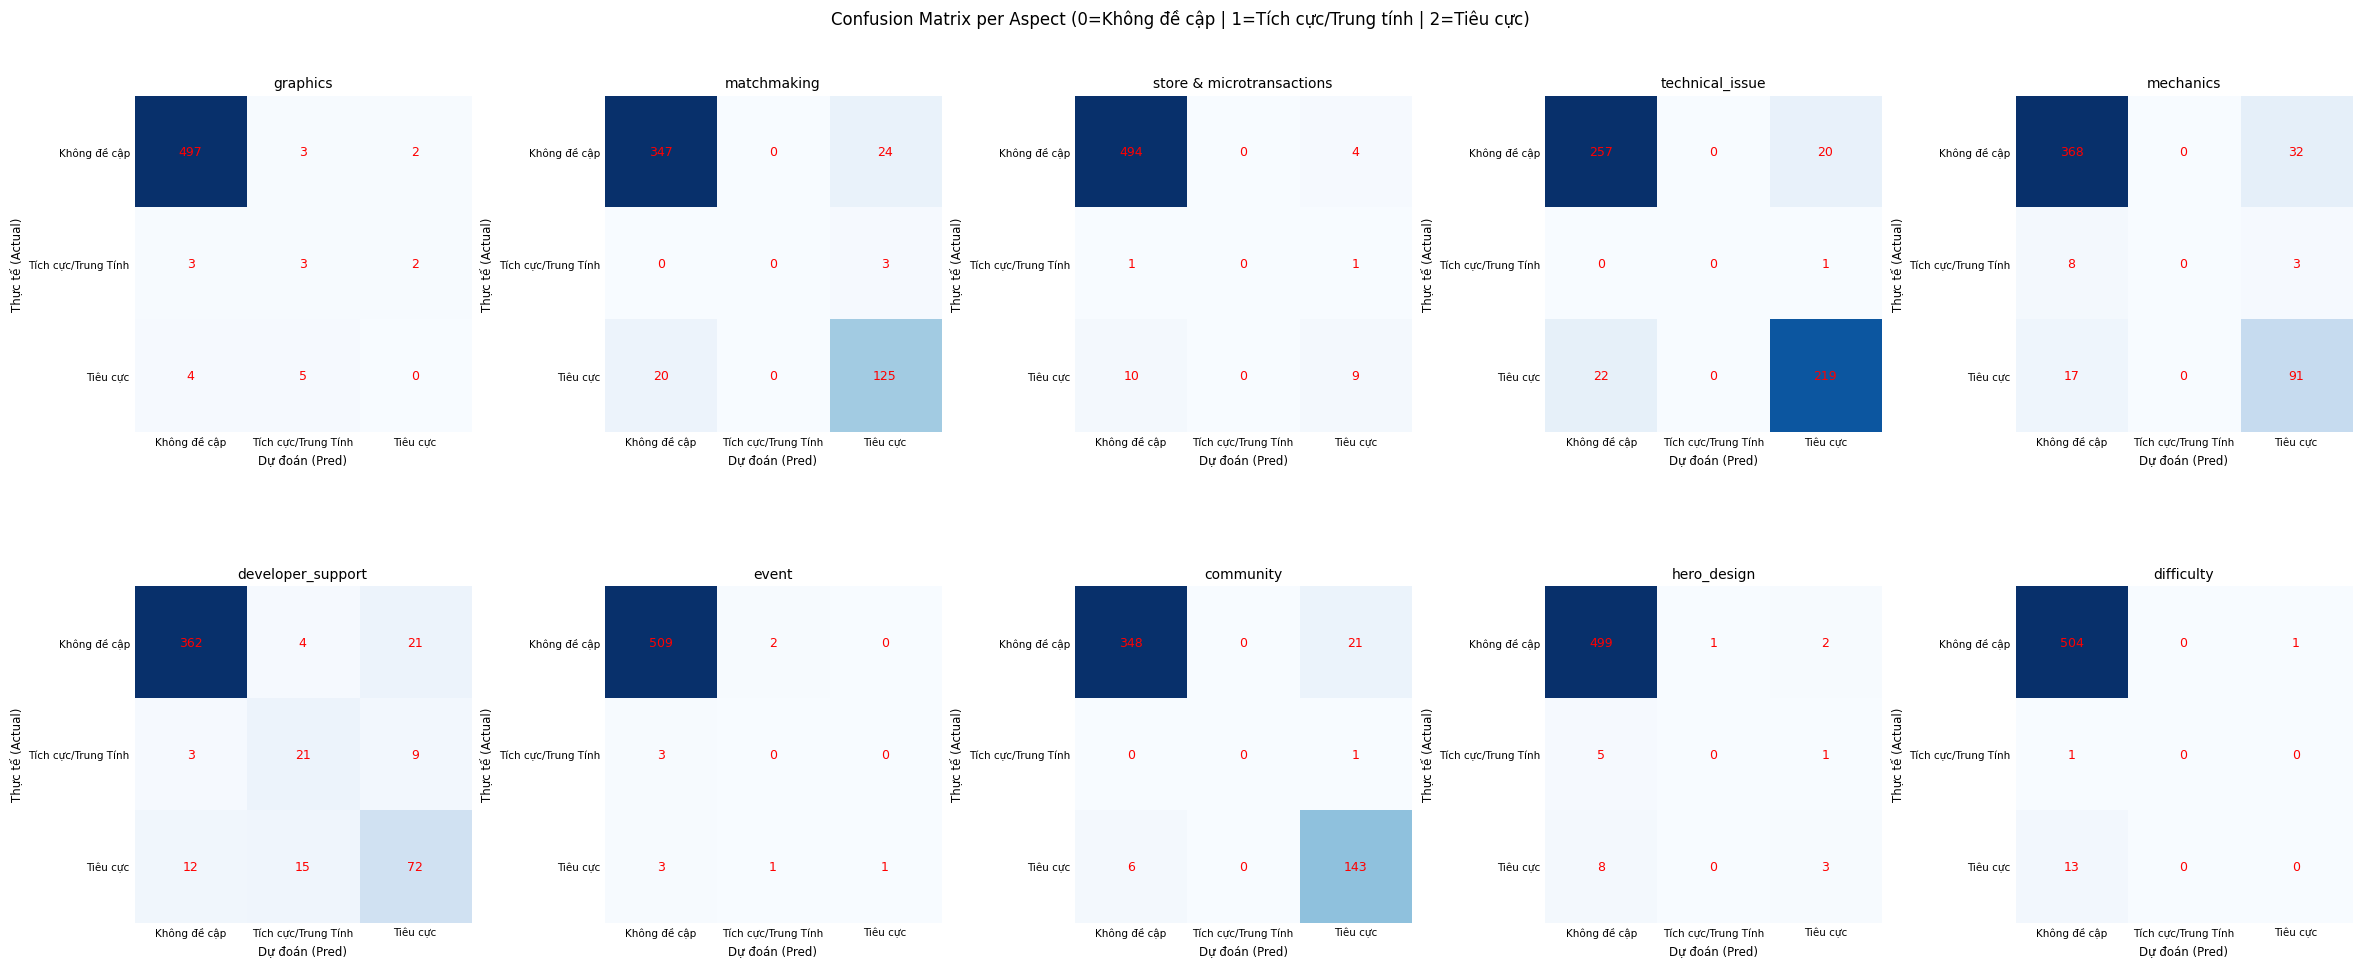

In [17]:
CLASS_LABELS = [0, 1, 2]
TICK_LABELS  = ["Không đề cập", "Tích cực/Trung Tính", "Tiêu cực"]
N_COLS = 5
n_aspects = len(ASPECT_COLS)
n_rows = (n_aspects + N_COLS - 1) // N_COLS
n_cls = len(CLASS_LABELS)
cell  = 1.1
fig_w = N_COLS * (n_cls * cell + 1.4)
fig_h = n_rows * (n_cls * cell + 1.6)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(fig_w, fig_h), constrained_layout=True)
axes = np.array(axes).reshape(-1)
fig.suptitle("Confusion Matrix per Aspect (0=Không đề cập | 1=Tích cực/Trung tính | 2=Tiêu cực)", y=1.01)
for idx, aspect in enumerate(ASPECT_COLS):
    ax = axes[idx]
    cm = confusion_matrix(labels[:, idx], preds[:, idx], labels=CLASS_LABELS)
    ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=max(cm.max(), 1))
    for i in range(n_cls):
        for j in range(n_cls):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9, color="red")
    ax.set_xticks(range(n_cls))
    ax.set_yticks(range(n_cls))
    ax.set_xticklabels(TICK_LABELS, fontsize=7.5)
    ax.set_yticklabels(TICK_LABELS, fontsize=7.5)
    ax.set_xlabel("Dự đoán (Pred)", fontsize=8.5)
    ax.set_ylabel("Thực tế (Actual)", fontsize=8.5)
    ax.set_title(aspect, fontsize=10, pad=6)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
for idx in range(n_aspects, len(axes)):
    axes[idx].set_visible(False)
plt.show()

In [18]:
pred_df = test_df.copy().reset_index(drop=True)
col_map = {aspect: f"{aspect}_actual" for aspect in ASPECT_COLS}
pred_df = pred_df.rename(columns=col_map)

for i, aspect in enumerate(ASPECT_COLS):
    pred_df[f"{aspect}_model_pred"] = preds[:, i]
    pred_df[f"{aspect}_match"] = (
        pred_df[f"{aspect}_actual"] == pred_df[f"{aspect}_model_pred"]
    )

pred_df["num_wrong_aspects"] = sum(
    (~pred_df[f"{aspect}_match"]).astype(int) for aspect in ASPECT_COLS
)
output_csv_path = OUTPUT_DIR / "test_predictions_with_errors.csv"
pred_df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")
print(f"Saved: {output_csv_path}")


Saved: /content/drive/MyDrive/IE403/LAMLAI/sentiment-analysis-game-domain/artifacts/predictions/xlm-roberta-base/test_predictions_with_errors.csv


### Kiểm tra các review mà model dự đoán sai

In [19]:
label = {0: "Không đề cập", 1: "Tích cực/Trung tính", 2: "Tiêu cực"}
for i in range(len(test_df[TEXT_COL])):
  for j, aspect in enumerate(ASPECT_COLS):
    true_label = labels[i][j]
    pred_label = preds[i][j]
    if true_label != pred_label:
      print(i)
      print(f"Aspect: {aspect}")
      print(f"True: {label[true_label]}")
      print(f"Predict: {label[pred_label]}")
      print(f"Review: {test_df[TEXT_COL].iloc[i]}")


2
Aspect: graphics
True: Không đề cập
Predict: Tiêu cực
Review: gắn bó với game cũng đã lâu và đầu tư rất nhiều tài nguyên vào game vì bản thân tôi thật sự khá thích game. tuy nhiên sau phiên bản cập nhật sinh nhật 9 tuổi thì tài khoản game tôi đang chơi lại bị mất trang phục, cụ thể là những trang phục trước đây sở hữu nhưng sau cập nhật thì lại không còn sở hữu nữa. các trang phục mất toàn là những bộ được mua từ shop và lấy từ sự kiện chung sức. đã đề đơn hỗ trợ cho bên phía hỗ trợ rồi mà tới giờ vẫn chưa có giải quyết. thật sự là quá thất vọng.
2
Aspect: event
True: Không đề cập
Predict: Tích cực/Trung tính
Review: gắn bó với game cũng đã lâu và đầu tư rất nhiều tài nguyên vào game vì bản thân tôi thật sự khá thích game. tuy nhiên sau phiên bản cập nhật sinh nhật 9 tuổi thì tài khoản game tôi đang chơi lại bị mất trang phục, cụ thể là những trang phục trước đây sở hữu nhưng sau cập nhật thì lại không còn sở hữu nữa. các trang phục mất toàn là những bộ được mua từ shop và lấy từ sự 

In [20]:
incorrect_reviews_count = 0
num_reviews = labels.shape[0]
for i in range(num_reviews):
    # kiểm tra review pred sai
    if (labels[i] != preds[i]).any():
        print(f"Review {i + 1}:")
        print(f"Review: {test_df[TEXT_COL].iloc[i]}")
        print(f"True labels: {labels[i]}")
        print(f"Predicted labels: {preds[i]}")
        incorrect_reviews_count += 1
print(f"Tổng số review có ít nhất một khía cạnh dự đoán sai: {incorrect_reviews_count}")
print(f"Tổng số review: {num_reviews}")


Review 3:
Review: gắn bó với game cũng đã lâu và đầu tư rất nhiều tài nguyên vào game vì bản thân tôi thật sự khá thích game. tuy nhiên sau phiên bản cập nhật sinh nhật 9 tuổi thì tài khoản game tôi đang chơi lại bị mất trang phục, cụ thể là những trang phục trước đây sở hữu nhưng sau cập nhật thì lại không còn sở hữu nữa. các trang phục mất toàn là những bộ được mua từ shop và lấy từ sự kiện chung sức. đã đề đơn hỗ trợ cho bên phía hỗ trợ rồi mà tới giờ vẫn chưa có giải quyết. thật sự là quá thất vọng.
True labels: [0 0 0 2 0 2 0 0 0 0]
Predicted labels: [2 0 0 2 0 2 1 0 0 0]
Review 6:
Review: ghép lệch rank vô cùng, 50 mấy sao gặp 10 mấy sao, tệ hại
True labels: [0 2 0 0 0 0 0 0 0 0]
Predicted labels: [0 2 0 0 0 0 0 2 0 0]
Review 9:
Review: chơi càng ngày làm sao tranh lean báo cáo lại không bị trừ còn trong team afk 2 3 người lại bị trừ sao lỗi nhiều đang chuẩn bị vô trận lại kêu đang kết nối vô để đăng nhập thì lại kêu là lỗi do mạng do đường dây không vô được mong nhà sản xuất sửa

In [21]:
all_reviews = []
num_reviews = labels.shape[0]

for i in range(num_reviews):
    all_reviews.append({
        "review_index": i + 1,
        "review": test_df[TEXT_COL].iloc[i],
        "true_labels": labels[i].tolist(),
        "predicted_labels": preds[i].tolist()
    })

pred_df = pd.DataFrame(all_reviews)
pred_df.to_csv(OUTPUT_DIR / "pred_reviews.json_style.csv", index=False, encoding="utf-8-sig")
